# 📊 Visualize Training Results — Spot Instance RL Agent

Notebook này giúp bạn **xem kết quả training** của DQN agent trong bài toán tối ưu chi phí EC2 Spot vs On-Demand.

**Nội dung:**
1. Load dữ liệu training từ `metrics.pkl`
2. Learning curves — Reward, Cost, SLA qua các episode
3. So sánh nhiều lần chạy (runs)
4. Phân bổ hành động (Action distribution)
5. Phân tích chi tiết từng episode
6. Tổng kết kết quả

In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Style chung cho tất cả biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

# Tên các action cho dễ đọc (7 actions)
ACTION_NAMES = [
    "Thêm Spot",        # 0: REQUEST_SPOT
    "Thêm On-Demand",   # 1: REQUEST_ONDEMAND
    "Giảm Spot",        # 2: TERMINATE_SPOT
    "Giảm On-Demand",   # 3: TERMINATE_ONDEMAND
    "Migrate → OD",     # 4: MIGRATE_TO_ONDEMAND
    "Migrate → Spot",   # 5: MIGRATE_TO_SPOT
    "Không làm gì",     # 6: DO_NOTHING
]

ACTION_COLORS = ['#2196F3', '#FF9800', '#F44336', '#E91E63', '#9C27B0', '#00BCD4', '#607D8B']

NUM_ACTIONS = len(ACTION_NAMES)  # 7

print("✅ Setup xong!")

✅ Setup xong!


## 1. Load dữ liệu training

Mỗi lần train sẽ lưu `metrics.pkl` chứa:
- `episode_rewards` — tổng reward mỗi episode
- `episode_costs` — chi phí ($) mỗi episode  
- `episode_sla_compliance` — tỷ lệ SLA (0-1)
- `episode_spot_usage` — tỷ lệ dùng spot instance
- `episode_info` — thông tin chi tiết (action counts, spot price, ...)

In [2]:
def load_metrics(pkl_path):
    """Load metrics từ file pickle."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    print(f"📂 Loaded: {pkl_path}")
    print(f"   Episodes: {len(data['episode_rewards'])}")
    print(f"   Keys: {list(data.keys())}")
    return data

def metrics_to_df(data, run_name=""):
    """Chuyển metrics dict thành DataFrame dễ xử lý."""
    df = pd.DataFrame({
        'episode': range(1, len(data['episode_rewards']) + 1),
        'reward': data['episode_rewards'],
        'cost': data['episode_costs'],
        'sla': data['episode_sla_compliance'],
        'spot_usage': data['episode_spot_usage'],
    })
    if run_name:
        df['run'] = run_name
    return df

# === LOAD CÁC LẦN CHẠY ===
# Tự động tìm tất cả metrics.pkl trong results/
results_dir = Path('../results')
all_runs = {}

for pkl_path in sorted(results_dir.rglob('metrics.pkl')):
    # Lấy tên run từ đường dẫn (vd: dqn_first_run, dqn_v2, ...)
    run_name = pkl_path.parts[-3]  # folder cha của timestamp
    all_runs[run_name] = load_metrics(pkl_path)

print(f"\n🎯 Tổng cộng {len(all_runs)} lần chạy: {list(all_runs.keys())}")

📂 Loaded: ..\results\quick_test\20260324_110257\metrics.pkl
   Episodes: 100
   Keys: ['episode_rewards', 'episode_costs', 'episode_sla_compliance', 'episode_spot_usage', 'episode_info']
📂 Loaded: ..\results\quick_test_v2\20260324_112301\metrics.pkl
   Episodes: 100
   Keys: ['episode_rewards', 'episode_costs', 'episode_sla_compliance', 'episode_spot_usage', 'episode_info']
📂 Loaded: ..\results\quick_test_v3\20260324_113015\metrics.pkl
   Episodes: 100
   Keys: ['episode_rewards', 'episode_costs', 'episode_sla_compliance', 'episode_spot_usage', 'episode_info']

🎯 Tổng cộng 3 lần chạy: ['quick_test', 'quick_test_v2', 'quick_test_v3']


In [3]:
# Xem thống kê nhanh của từng run
summary_rows = []
for name, data in all_runs.items():
    n = len(data['episode_rewards'])
    # Lấy 100 episode cuối để đánh giá convergence
    last_100 = slice(-min(100, n), None)
    summary_rows.append({
        'Run': name,
        'Episodes': n,
        'Avg Reward (last 100)': f"{np.mean(data['episode_rewards'][last_100]):.1f}",
        'Avg Cost (last 100)': f"${np.mean(data['episode_costs'][last_100]):.0f}",
        'Avg SLA (last 100)': f"{np.mean(data['episode_sla_compliance'][last_100]):.1%}",
        'Avg Spot Usage (last 100)': f"{np.mean(data['episode_spot_usage'][last_100]):.1%}",
    })

pd.DataFrame(summary_rows).set_index('Run')

,Episodes,Avg Reward (last 100),Avg Cost (last 100),Avg SLA (last 100),Avg Spot Usage (last 100)
Run,,,,,
quick_test,100,-3016.0,$150,58.7%,68.9%
quick_test_v2,100,1943.8,$95,42.1%,51.2%
quick_test_v3,100,-517.9,$150,60.6%,65.6%


## 2. Learning Curves — Agent học được gì qua thời gian?

Ba biểu đồ quan trọng nhất:
- **Reward** ↑ càng cao càng tốt — agent tối ưu được cost savings
- **Cost** ↓ càng thấp càng tốt — chi phí thực tế giảm
- **SLA** ↑ phải ≥ 95% — đảm bảo job không bị fail

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\962935770.py:37: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from current font.
  plt.tight_layout()
C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\962935770.py:37: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


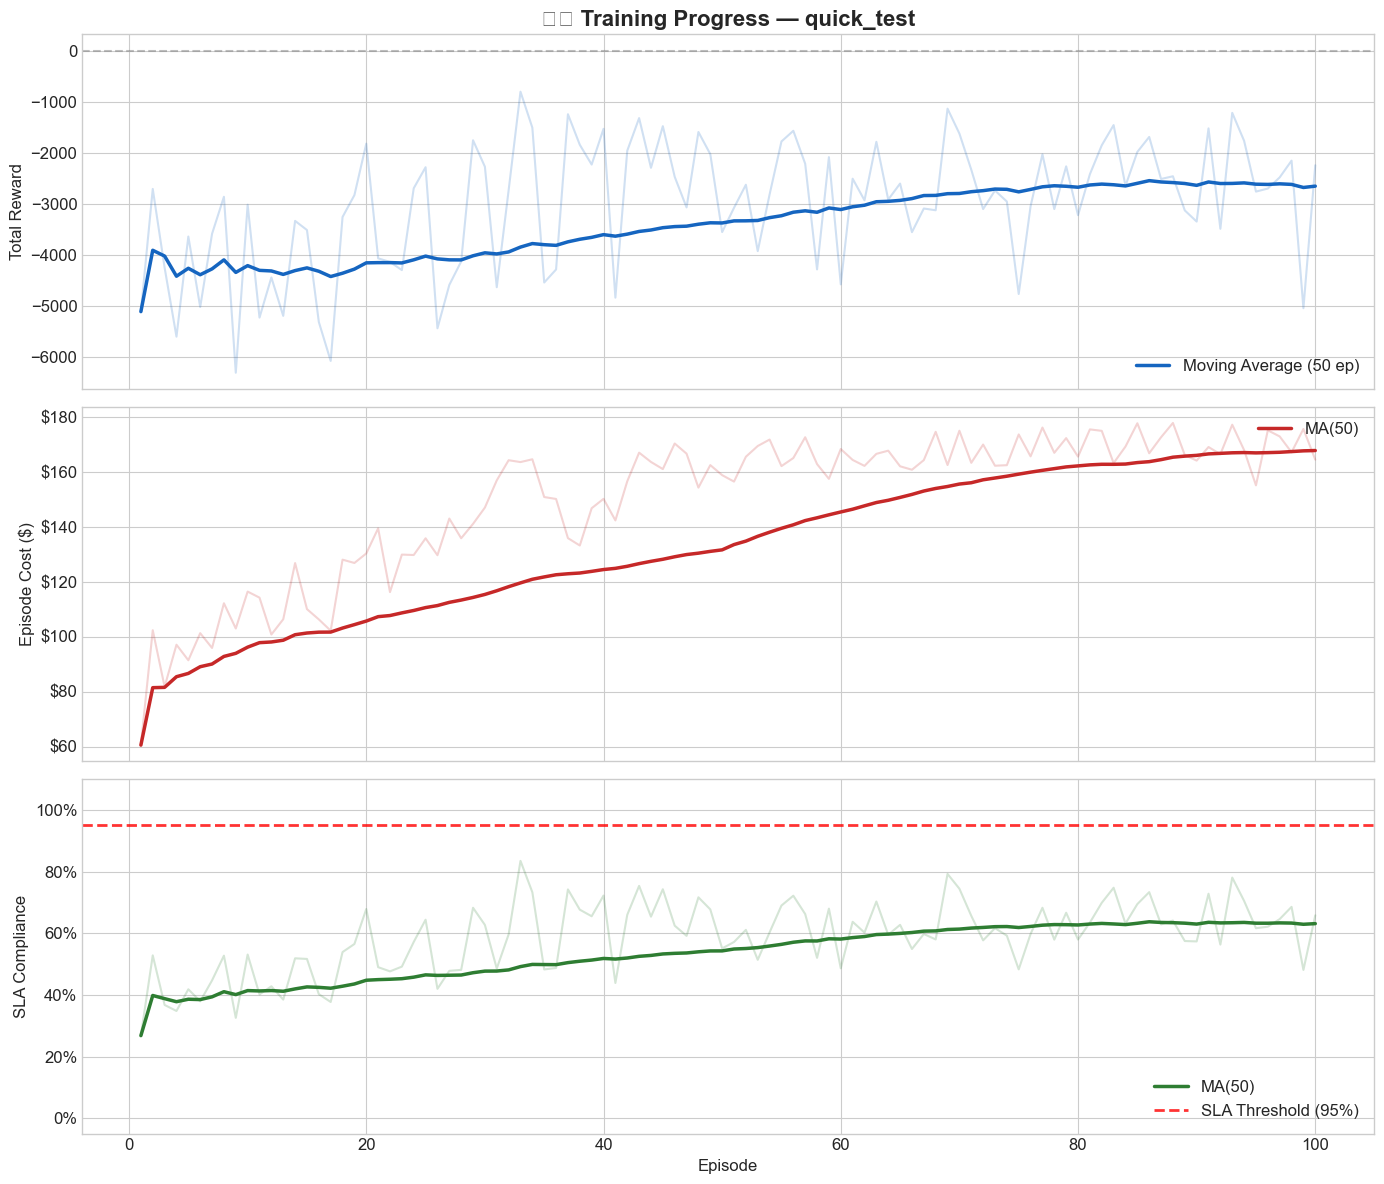

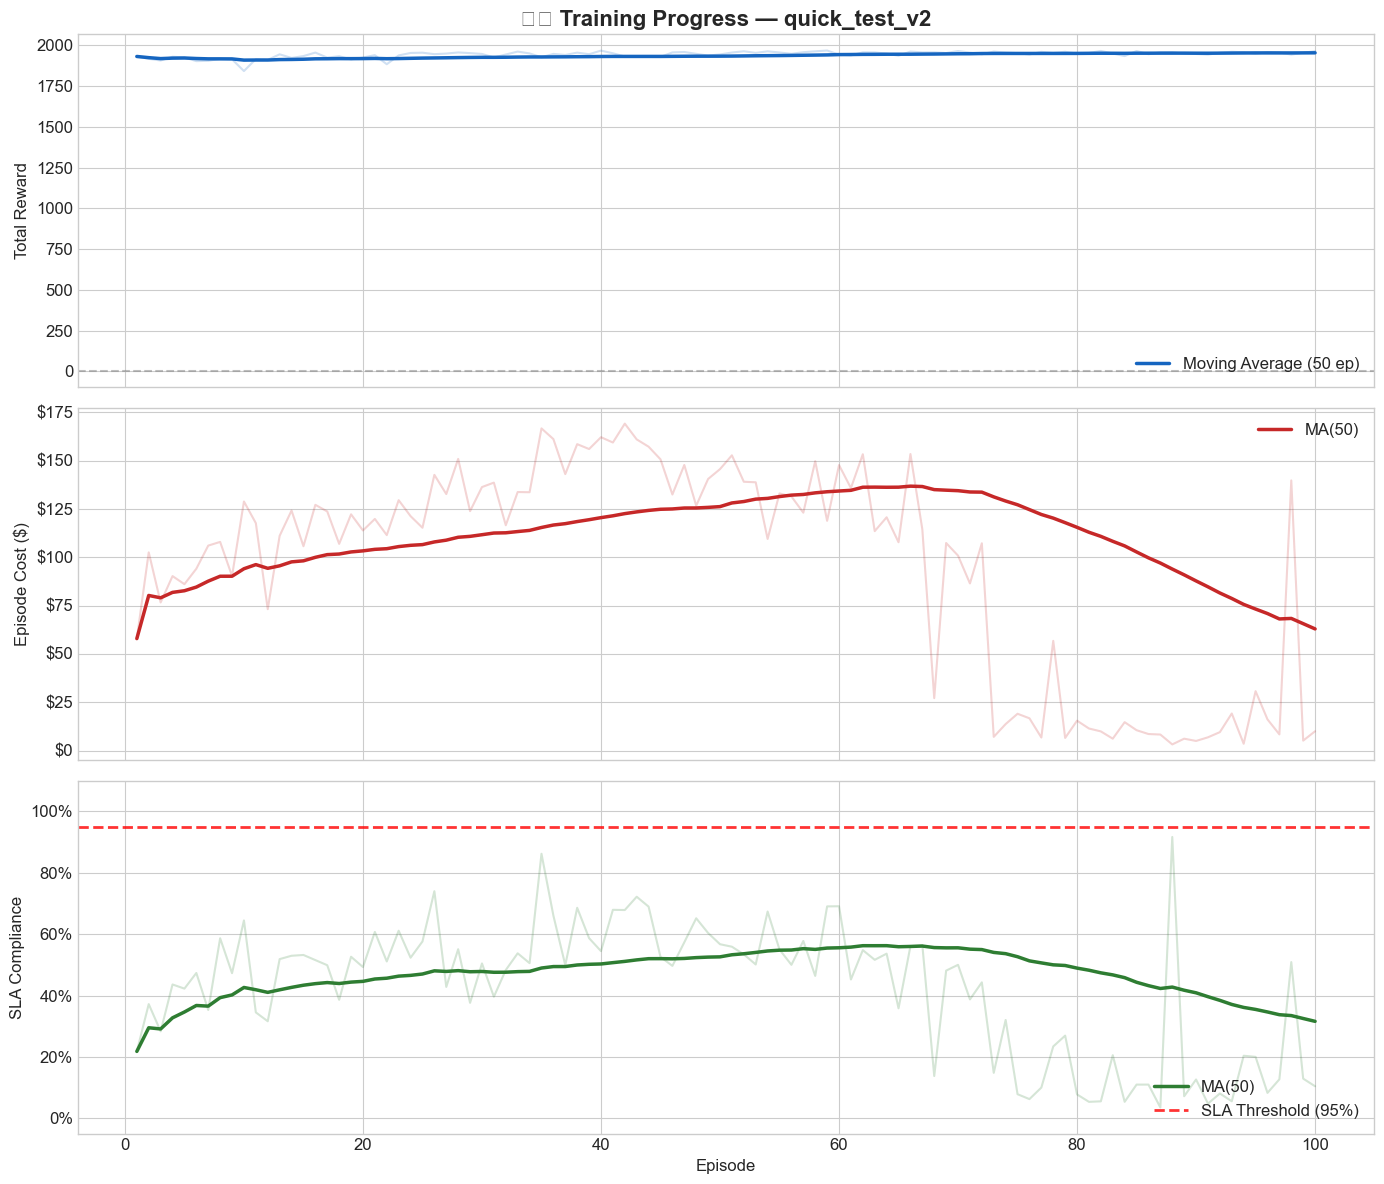

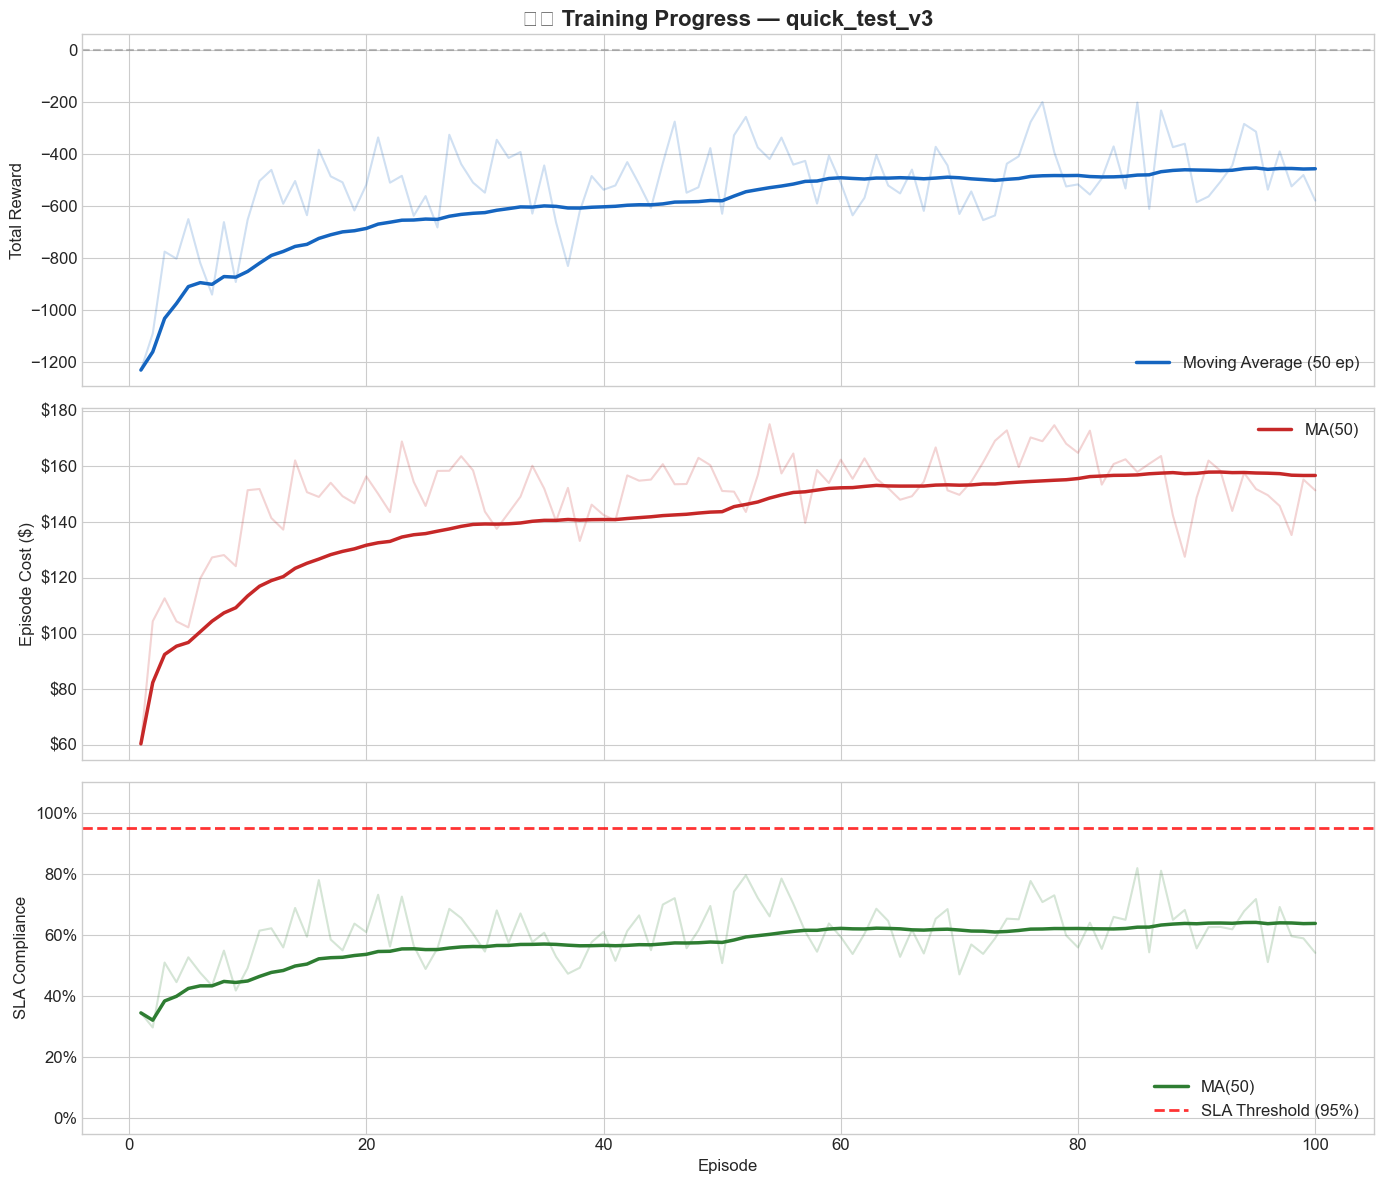

In [4]:
def plot_learning_curves(data, run_name, window=50):
    """Vẽ learning curves cho 1 run."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    episodes = np.arange(1, len(data['episode_rewards']) + 1)
    
    def smooth(values, w):
        return pd.Series(values).rolling(window=w, min_periods=1).mean().values

    # --- Reward ---
    axes[0].plot(episodes, data['episode_rewards'], alpha=0.2, color='#1565C0')
    axes[0].plot(episodes, smooth(data['episode_rewards'], window), 
                 color='#1565C0', linewidth=2.5, label=f'Moving Average ({window} ep)')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title(f'🏋️ Training Progress — {run_name}', fontsize=16, fontweight='bold')
    axes[0].legend(loc='lower right')

    # --- Cost ---
    axes[1].plot(episodes, data['episode_costs'], alpha=0.2, color='#C62828')
    axes[1].plot(episodes, smooth(data['episode_costs'], window),
                 color='#C62828', linewidth=2.5, label=f'MA({window})')
    axes[1].set_ylabel('Episode Cost ($)')
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    axes[1].legend(loc='upper right')

    # --- SLA ---
    axes[2].plot(episodes, data['episode_sla_compliance'], alpha=0.2, color='#2E7D32')
    axes[2].plot(episodes, smooth(data['episode_sla_compliance'], window),
                 color='#2E7D32', linewidth=2.5, label=f'MA({window})')
    axes[2].axhline(y=0.95, color='red', linestyle='--', linewidth=2, alpha=0.8, label='SLA Threshold (95%)')
    axes[2].set_ylabel('SLA Compliance')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylim(-0.05, 1.1)
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# Vẽ cho từng run
for name, data in all_runs.items():
    plot_learning_curves(data, name)

## 3. So sánh các lần chạy (Run Comparison)

Đặt các run cạnh nhau để thấy run nào cho kết quả tốt nhất.

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\1028358119.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


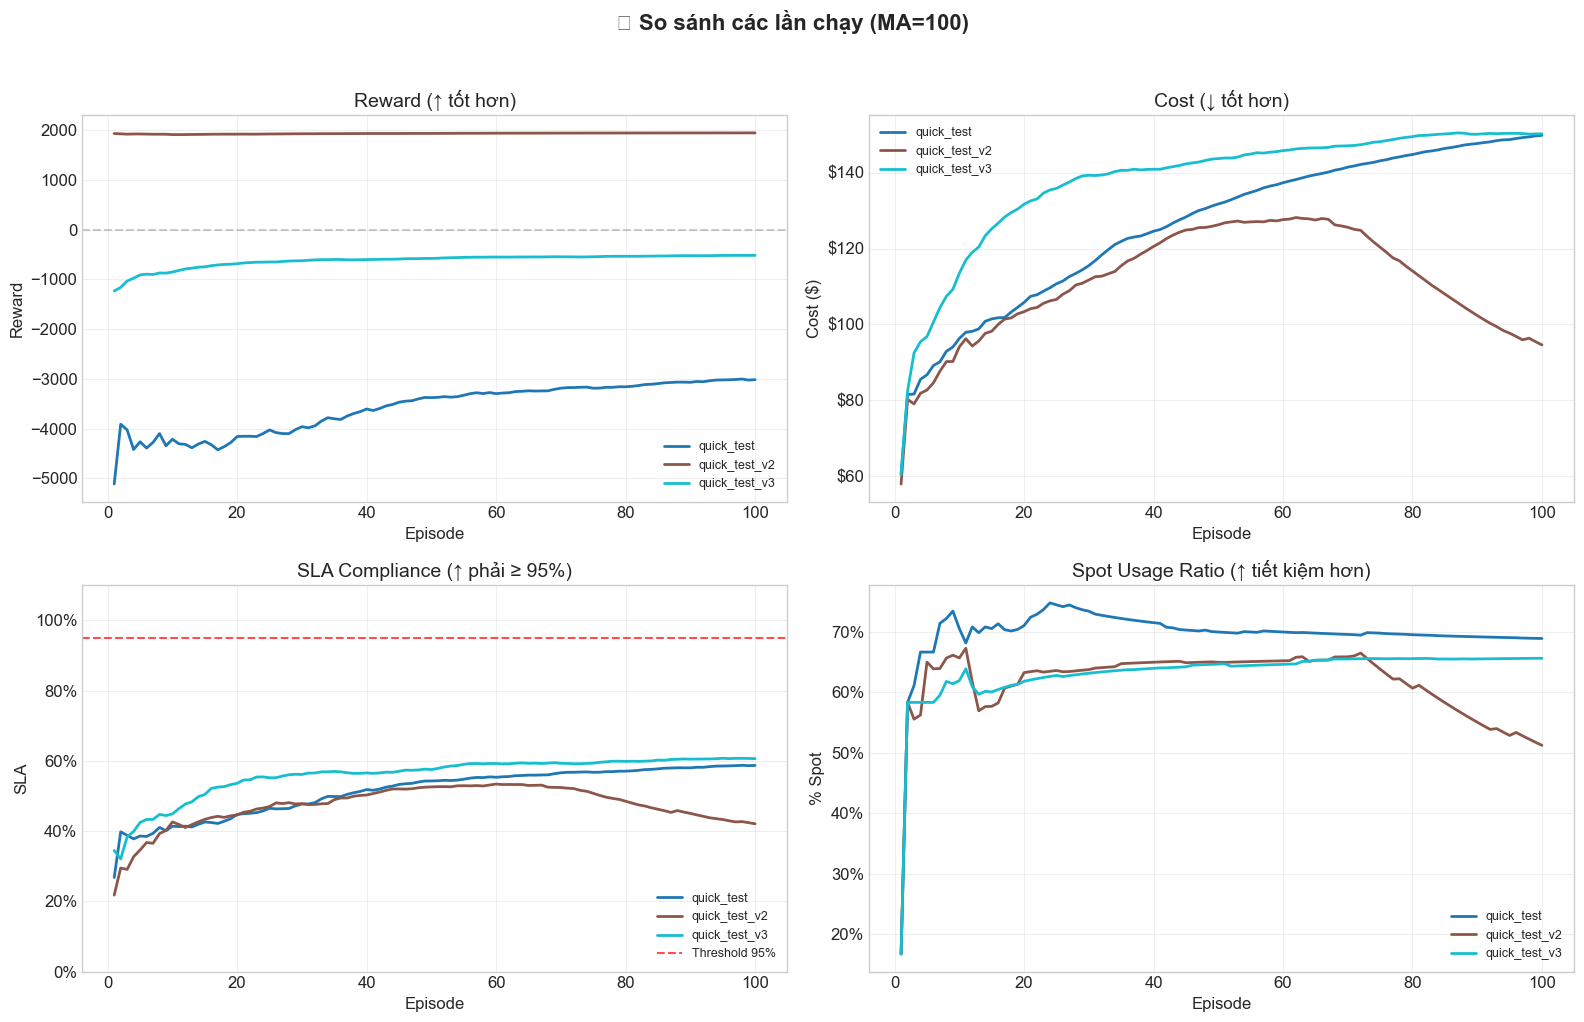

In [5]:
def plot_runs_comparison(all_runs, window=100):
    """So sánh reward, cost, SLA giữa các runs trên cùng 1 biểu đồ."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_runs)))
    
    def smooth(values, w):
        return pd.Series(values).rolling(window=w, min_periods=1).mean().values

    for i, (name, data) in enumerate(all_runs.items()):
        episodes = np.arange(1, len(data['episode_rewards']) + 1)
        c = colors[i]
        
        # Reward (smoothed)
        axes[0, 0].plot(episodes, smooth(data['episode_rewards'], window), 
                        color=c, linewidth=2, label=name)
        # Cost (smoothed)
        axes[0, 1].plot(episodes, smooth(data['episode_costs'], window),
                        color=c, linewidth=2, label=name)
        # SLA (smoothed)
        axes[1, 0].plot(episodes, smooth(data['episode_sla_compliance'], window),
                        color=c, linewidth=2, label=name)
        # Spot usage (smoothed)
        axes[1, 1].plot(episodes, smooth(data['episode_spot_usage'], window),
                        color=c, linewidth=2, label=name)

    axes[0, 0].set_title('Reward (↑ tốt hơn)')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
    
    axes[0, 1].set_title('Cost (↓ tốt hơn)')
    axes[0, 1].set_ylabel('Cost ($)')
    axes[0, 1].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    
    axes[1, 0].set_title('SLA Compliance (↑ phải ≥ 95%)')
    axes[1, 0].set_ylabel('SLA')
    axes[1, 0].axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='Threshold 95%')
    axes[1, 0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1, 0].set_ylim(0, 1.1)
    
    axes[1, 1].set_title('Spot Usage Ratio (↑ tiết kiệm hơn)')
    axes[1, 1].set_ylabel('% Spot')
    axes[1, 1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    for ax in axes.flat:
        ax.set_xlabel('Episode')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'📈 So sánh các lần chạy (MA={window})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_runs_comparison(all_runs)

## 4. Action Distribution — Agent chọn hành động gì?

Xem agent thiên về dùng Spot hay On-Demand, có hay migrate không, v.v.
Điều này cho thấy **chiến lược** mà agent đã học được.

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\1431460875.py:38: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


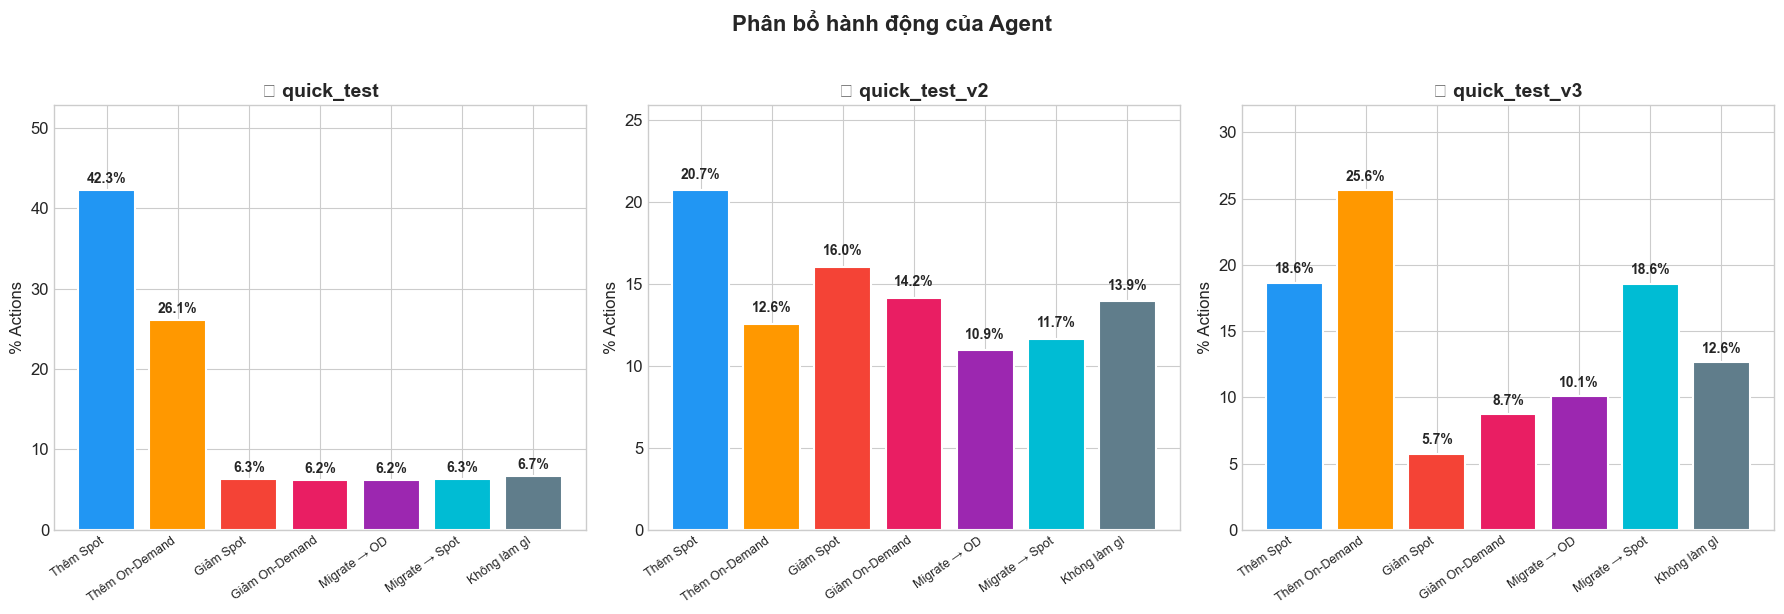

In [6]:
def plot_action_dist(all_runs):
    """Vẽ action distribution cho từng run (lấy từ episode_info)."""
    n_runs = len(all_runs)
    fig, axes = plt.subplots(1, n_runs, figsize=(6 * n_runs, 6), squeeze=False)
    
    for idx, (name, data) in enumerate(all_runs.items()):
        ax = axes[0, idx]
        
        # Tổng hợp action_counts từ tất cả episode info
        # Tương thích cả data cũ (6 actions) và mới (7 actions)
        total_actions = np.zeros(NUM_ACTIONS)
        for info in data['episode_info']:
            if 'action_counts' in info:
                ac = np.array(info['action_counts'])
                if len(ac) <= NUM_ACTIONS:
                    total_actions[:len(ac)] += ac
        
        if total_actions.sum() == 0:
            ax.text(0.5, 0.5, 'Không có action_counts', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(name)
            continue
        
        pcts = total_actions / total_actions.sum() * 100
        bars = ax.bar(range(NUM_ACTIONS), pcts, color=ACTION_COLORS, edgecolor='white', linewidth=1.5)
        
        for bar, pct in zip(bars, pcts):
            if pct > 1:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_xticks(range(NUM_ACTIONS))
        ax.set_xticklabels(ACTION_NAMES, rotation=35, ha='right', fontsize=9)
        ax.set_ylabel('% Actions')
        ax.set_title(f'🎯 {name}', fontweight='bold')
        ax.set_ylim(0, max(pcts) * 1.25)
    
    fig.suptitle('Phân bổ hành động của Agent', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_action_dist(all_runs)

## 5. Action thay đổi theo thời gian training

Xem agent thay đổi chiến lược thế nào — ban đầu (explore) vs cuối (exploit).

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\892458413.py:48: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


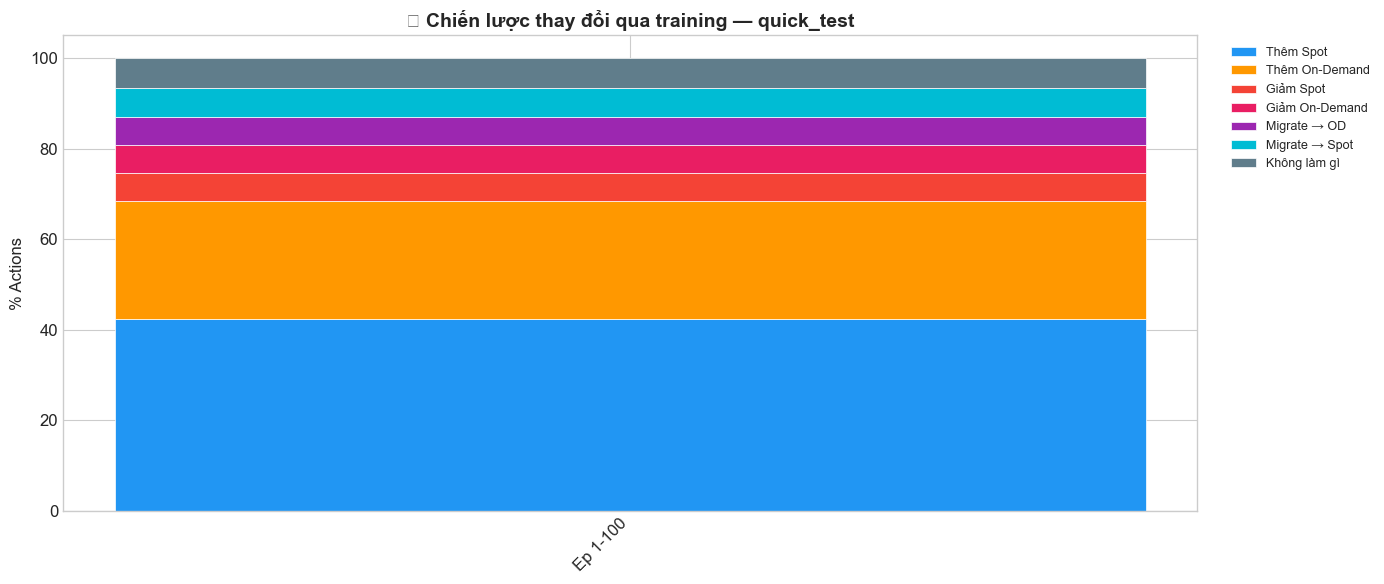

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\892458413.py:48: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


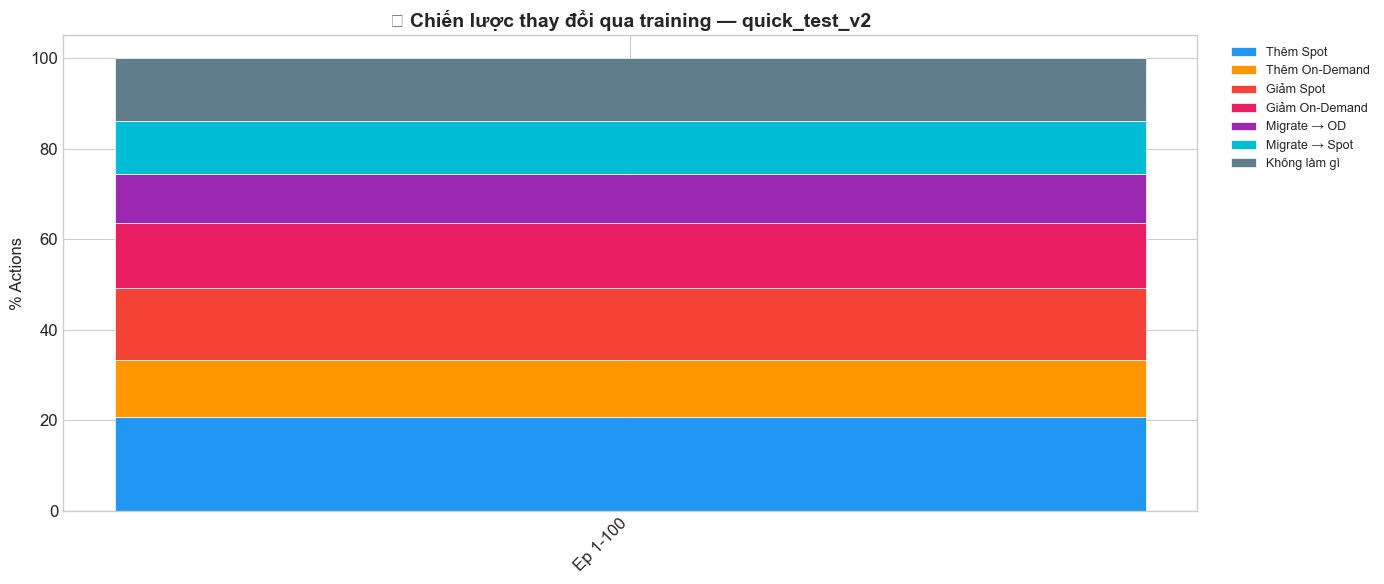

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\892458413.py:48: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


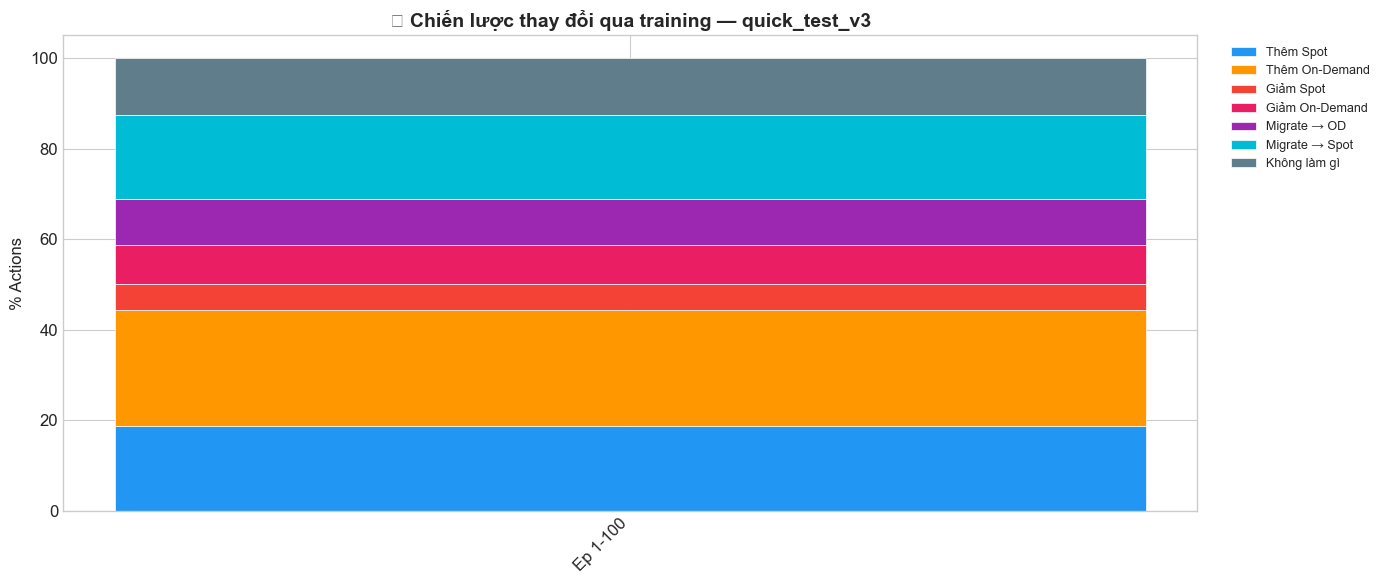

In [7]:
def plot_action_evolution(data, run_name, chunk_size=200):
    """Xem action distribution thay đổi qua training (chia thành chunks)."""
    infos = data['episode_info']
    n = len(infos)
    n_chunks = max(1, n // chunk_size)
    
    # Tính action distribution cho từng chunk
    # Tương thích cả data cũ (6 actions) và mới (7 actions)
    chunk_labels = []
    chunk_actions = []
    
    for i in range(n_chunks):
        start = i * chunk_size
        end = min(start + chunk_size, n)
        actions = np.zeros(NUM_ACTIONS)
        for info in infos[start:end]:
            if 'action_counts' in info:
                ac = np.array(info['action_counts'])
                if len(ac) <= NUM_ACTIONS:
                    actions[:len(ac)] += ac
        total = actions.sum()
        if total > 0:
            actions = actions / total * 100
        chunk_actions.append(actions)
        chunk_labels.append(f'Ep {start+1}-{end}')
    
    if not chunk_actions:
        print(f"⚠️ {run_name}: Không có action_counts data")
        return
    
    chunk_actions = np.array(chunk_actions)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(chunk_labels))
    bottom = np.zeros(len(chunk_labels))
    
    for a in range(NUM_ACTIONS):
        ax.bar(x, chunk_actions[:, a], bottom=bottom, color=ACTION_COLORS[a], 
               label=ACTION_NAMES[a], edgecolor='white', linewidth=0.5)
        bottom += chunk_actions[:, a]
    
    ax.set_xticks(x)
    ax.set_xticklabels(chunk_labels, rotation=45, ha='right')
    ax.set_ylabel('% Actions')
    ax.set_title(f'🔄 Chiến lược thay đổi qua training — {run_name}', fontweight='bold')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

# Chọn run mới nhất hoặc run chính để vẽ
for name, data in all_runs.items():
    plot_action_evolution(data, name)

## 6. Cost vs SLA Trade-off

Biểu đồ scatter thể hiện sự đánh đổi giữa **tiết kiệm chi phí** và **đảm bảo SLA**.
Mỗi điểm là 1 episode — điểm lý tưởng nằm ở **góc dưới-phải** (chi phí thấp, SLA cao).

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\3698374713.py:32: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


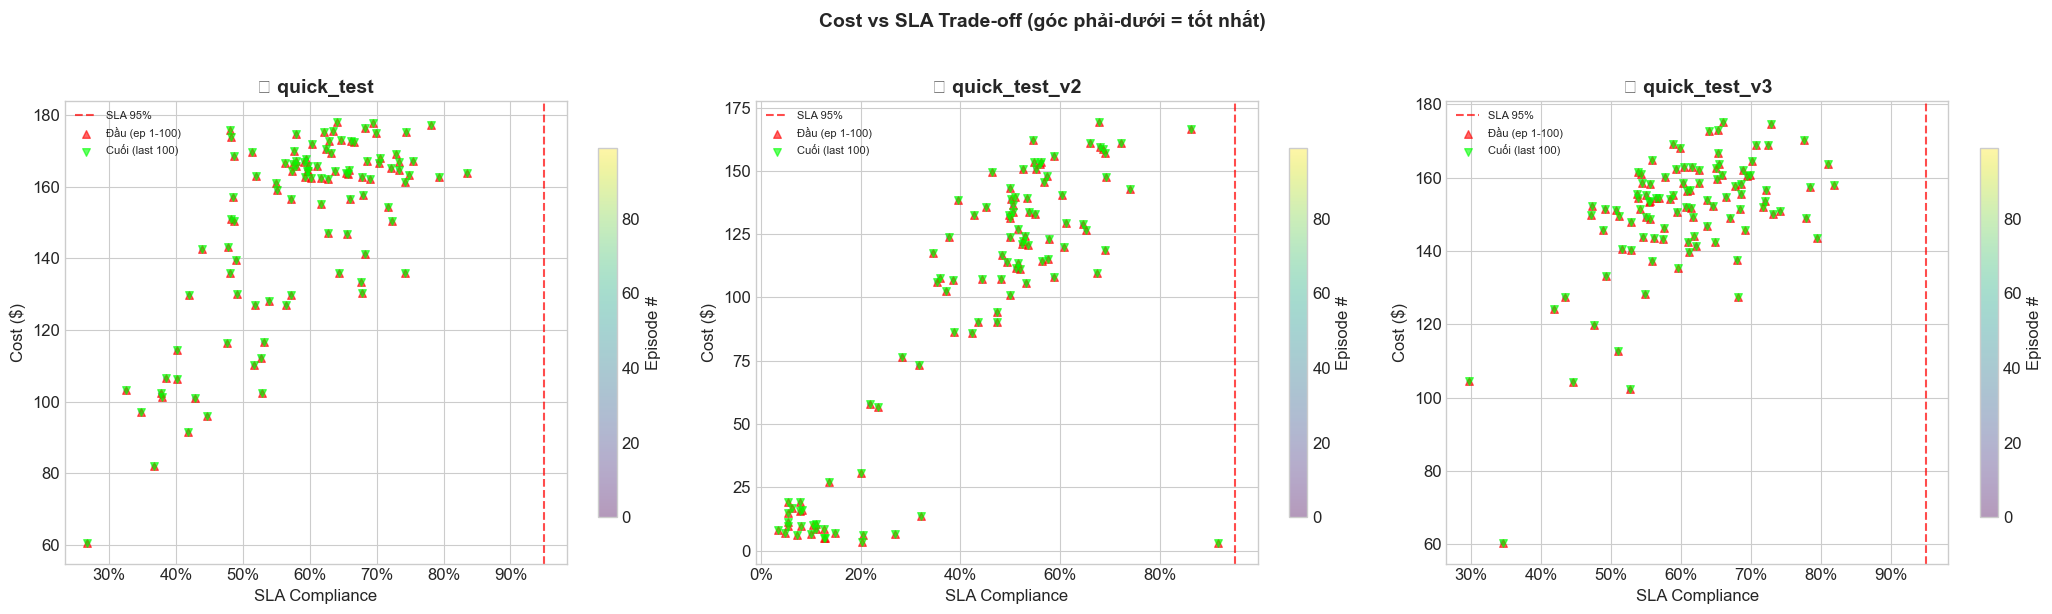

In [8]:
def plot_cost_sla_tradeoff(all_runs):
    """Scatter plot: Cost vs SLA, màu theo giai đoạn training."""
    n_runs = len(all_runs)
    fig, axes = plt.subplots(1, n_runs, figsize=(7 * n_runs, 6), squeeze=False)
    
    for idx, (name, data) in enumerate(all_runs.items()):
        ax = axes[0, idx]
        costs = np.array(data['episode_costs'])
        slas = np.array(data['episode_sla_compliance'])
        episodes = np.arange(len(costs))
        
        scatter = ax.scatter(slas, costs, c=episodes, cmap='viridis', 
                           alpha=0.4, s=15, edgecolors='none')
        plt.colorbar(scatter, ax=ax, label='Episode #', shrink=0.8)
        
        # Vùng lý tưởng
        ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.7, label='SLA 95%')
        
        # Đánh dấu 100 episode đầu vs cuối
        ax.scatter(slas[:100], costs[:100], color='red', s=30, alpha=0.6, 
                  label='Đầu (ep 1-100)', zorder=5, marker='^')
        ax.scatter(slas[-100:], costs[-100:], color='lime', s=30, alpha=0.6,
                  label='Cuối (last 100)', zorder=5, marker='v')
        
        ax.set_xlabel('SLA Compliance')
        ax.set_ylabel('Cost ($)')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.set_title(f'💰 {name}', fontweight='bold')
        ax.legend(fontsize=8, loc='upper left')
    
    fig.suptitle('Cost vs SLA Trade-off (góc phải-dưới = tốt nhất)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_cost_sla_tradeoff(all_runs)

## 7. Chi tiết Episode — Spot Price, Instances, Jobs

Zoom vào 1 episode cụ thể để hiểu agent quyết định thế nào tại từng bước.
Thông tin lấy từ `episode_info` cuối cùng của mỗi run.

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\503732020.py:50: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


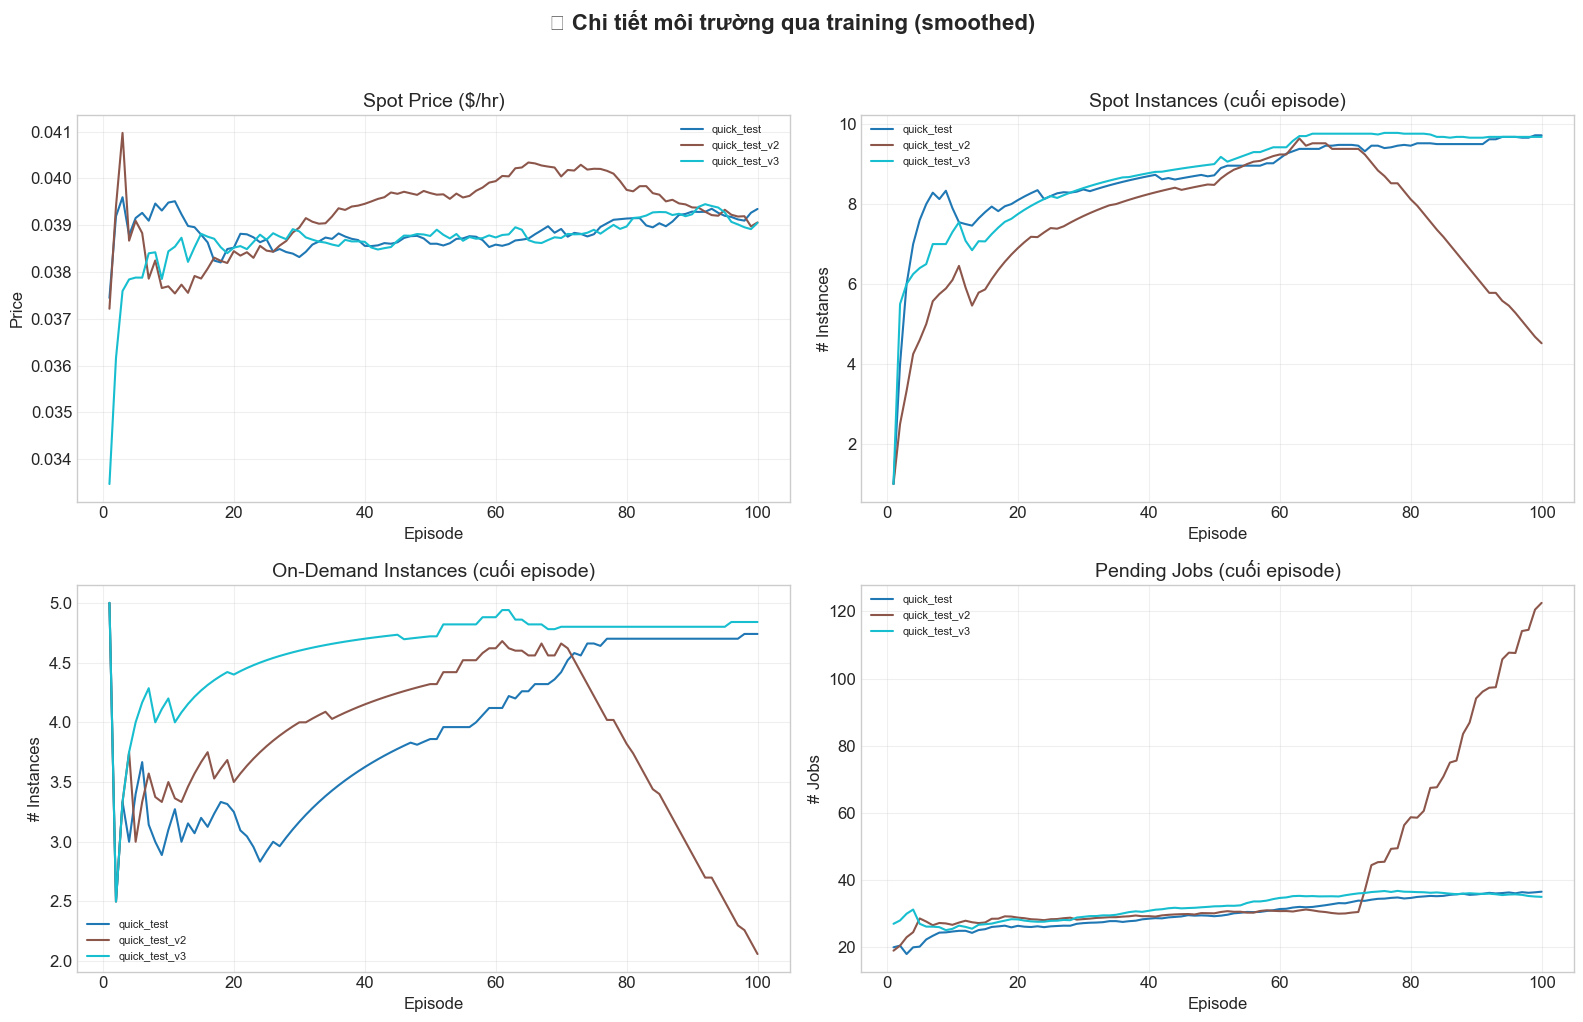

In [9]:
def plot_episode_details(all_runs):
    """Vẽ thông tin chi tiết: spot price, instances, jobs theo episode."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_runs)))
    
    def smooth(values, w=50):
        return pd.Series(values).rolling(window=w, min_periods=1).mean().values
    
    for i, (name, data) in enumerate(all_runs.items()):
        c = colors[i]
        infos = data['episode_info']
        
        # Trích xuất thông tin từ episode_info
        spot_prices = [info.get('spot_price', 0) for info in infos]
        spot_inst = [info.get('spot_instances', 0) for info in infos]
        od_inst = [info.get('ondemand_instances', 0) for info in infos]
        pending = [info.get('pending_jobs', 0) for info in infos]
        episodes = np.arange(1, len(infos) + 1)
        
        # Spot price cuối mỗi episode
        axes[0, 0].plot(episodes, smooth(spot_prices), color=c, linewidth=1.5, label=name)
        
        # Số spot instances
        axes[0, 1].plot(episodes, smooth(spot_inst), color=c, linewidth=1.5, label=name)
        
        # Số on-demand instances
        axes[1, 0].plot(episodes, smooth(od_inst), color=c, linewidth=1.5, label=name)
        
        # Pending jobs
        axes[1, 1].plot(episodes, smooth(pending), color=c, linewidth=1.5, label=name)
    
    axes[0, 0].set_title('Spot Price ($/hr)')
    axes[0, 0].set_ylabel('Price')
    
    axes[0, 1].set_title('Spot Instances (cuối episode)')
    axes[0, 1].set_ylabel('# Instances')
    
    axes[1, 0].set_title('On-Demand Instances (cuối episode)')
    axes[1, 0].set_ylabel('# Instances')
    
    axes[1, 1].set_title('Pending Jobs (cuối episode)')
    axes[1, 1].set_ylabel('# Jobs')

    for ax in axes.flat:
        ax.set_xlabel('Episode')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('📋 Chi tiết môi trường qua training (smoothed)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_episode_details(all_runs)

## 8. Tổng kết — Bảng so sánh cuối cùng

So sánh performance của tất cả runs dựa trên 100 episode cuối (sau khi converge).

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\3315962787.py:67: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\3315962787.py:67: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\3315962787.py:67: UserWarning: Glyph 9729 (\N{CLOUD}) missing from current font.
  plt.tight_layout()
C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\3315962787.py:67: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919

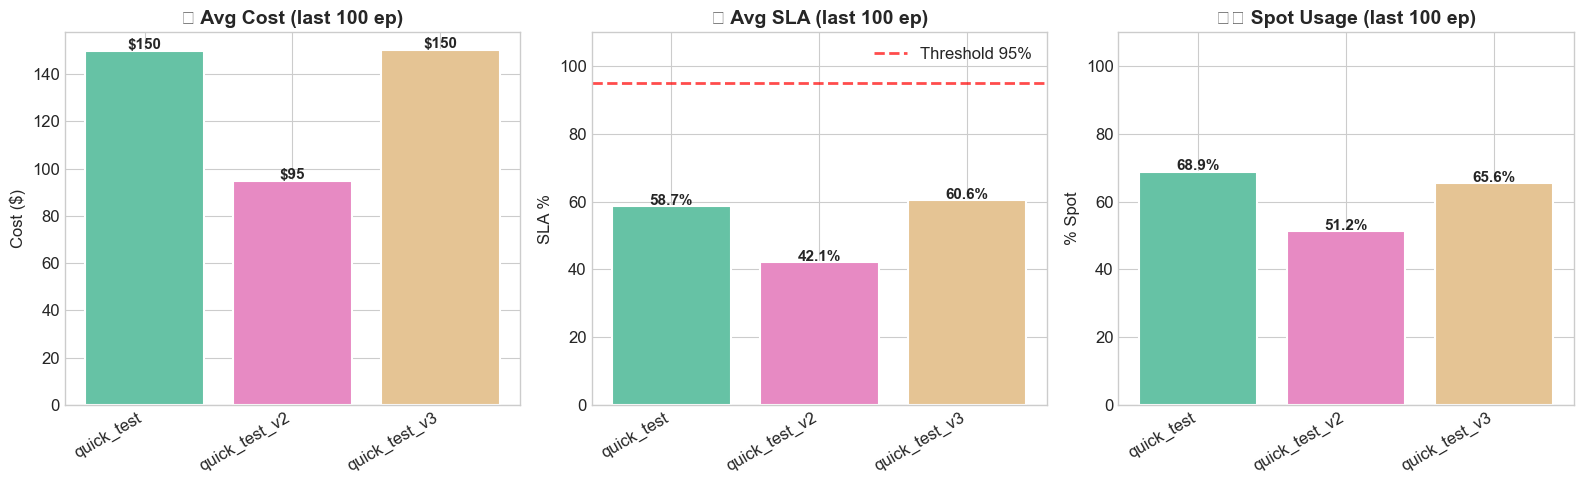

,Episodes,Avg Reward,Avg Cost ($),Avg SLA,SLA Violations,Spot Usage
Run,,,,,,
quick_test,100,-3016.0,$150,58.7%,100/100,68.9%
quick_test_v2,100,1943.8,$95,42.1%,100/100,51.2%
quick_test_v3,100,-517.9,$150,60.6%,100/100,65.6%


In [10]:
def final_summary(all_runs):
    """Bảng tổng kết + bar chart so sánh."""
    rows = []
    for name, data in all_runs.items():
        n = len(data['episode_rewards'])
        last = min(100, n)
        
        avg_reward = np.mean(data['episode_rewards'][-last:])
        avg_cost = np.mean(data['episode_costs'][-last:])
        avg_sla = np.mean(data['episode_sla_compliance'][-last:])
        avg_spot = np.mean(data['episode_spot_usage'][-last:])
        sla_violations = sum(1 for s in data['episode_sla_compliance'][-last:] if s < 0.95)
        
        rows.append({
            'Run': name,
            'Episodes': n,
            'Avg Reward': avg_reward,
            'Avg Cost ($)': avg_cost,
            'Avg SLA': avg_sla,
            'SLA Violations': f"{sla_violations}/{last}",
            'Spot Usage': avg_spot,
        })
    
    df = pd.DataFrame(rows).set_index('Run')
    
    # Bar chart so sánh
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    runs = df.index.tolist()
    x = np.arange(len(runs))
    bar_colors = plt.cm.Set2(np.linspace(0, 0.8, len(runs)))
    
    # Cost
    bars = axes[0].bar(x, df['Avg Cost ($)'], color=bar_colors, edgecolor='white', linewidth=1.5)
    for b, val in zip(bars, df['Avg Cost ($)']):
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                    f'${val:.0f}', ha='center', fontweight='bold', fontsize=11)
    axes[0].set_title('💵 Avg Cost (last 100 ep)', fontweight='bold')
    axes[0].set_ylabel('Cost ($)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(runs, rotation=30, ha='right')
    
    # SLA
    bars = axes[1].bar(x, df['Avg SLA'] * 100, color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Threshold 95%')
    for b, val in zip(bars, df['Avg SLA']):
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                    f'{val:.1%}', ha='center', fontweight='bold', fontsize=11)
    axes[1].set_title('🎯 Avg SLA (last 100 ep)', fontweight='bold')
    axes[1].set_ylabel('SLA %')
    axes[1].set_ylim(0, 110)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(runs, rotation=30, ha='right')
    axes[1].legend()
    
    # Spot Usage
    bars = axes[2].bar(x, df['Spot Usage'] * 100, color=bar_colors, edgecolor='white', linewidth=1.5)
    for b, val in zip(bars, df['Spot Usage']):
        axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                    f'{val:.1%}', ha='center', fontweight='bold', fontsize=11)
    axes[2].set_title('☁️ Spot Usage (last 100 ep)', fontweight='bold')
    axes[2].set_ylabel('% Spot')
    axes[2].set_ylim(0, 110)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(runs, rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Format bảng
    styled = df.copy()
    styled['Avg Reward'] = styled['Avg Reward'].map('{:.1f}'.format)
    styled['Avg Cost ($)'] = styled['Avg Cost ($)'].map('${:.0f}'.format)
    styled['Avg SLA'] = styled['Avg SLA'].map('{:.1%}'.format)
    styled['Spot Usage'] = styled['Spot Usage'].map('{:.1%}'.format)
    return styled

final_summary(all_runs)

## 9. Reward Distribution — Phân bố reward theo giai đoạn

So sánh phân bố reward giữa giai đoạn đầu (exploration) và cuối (exploitation) để thấy agent cải thiện bao nhiêu.

C:\Users\LOC\AppData\Local\Temp\ipykernel_16784\266450331.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
d:\Document\Seminar_MLOps\spot-rl-optimiztion\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


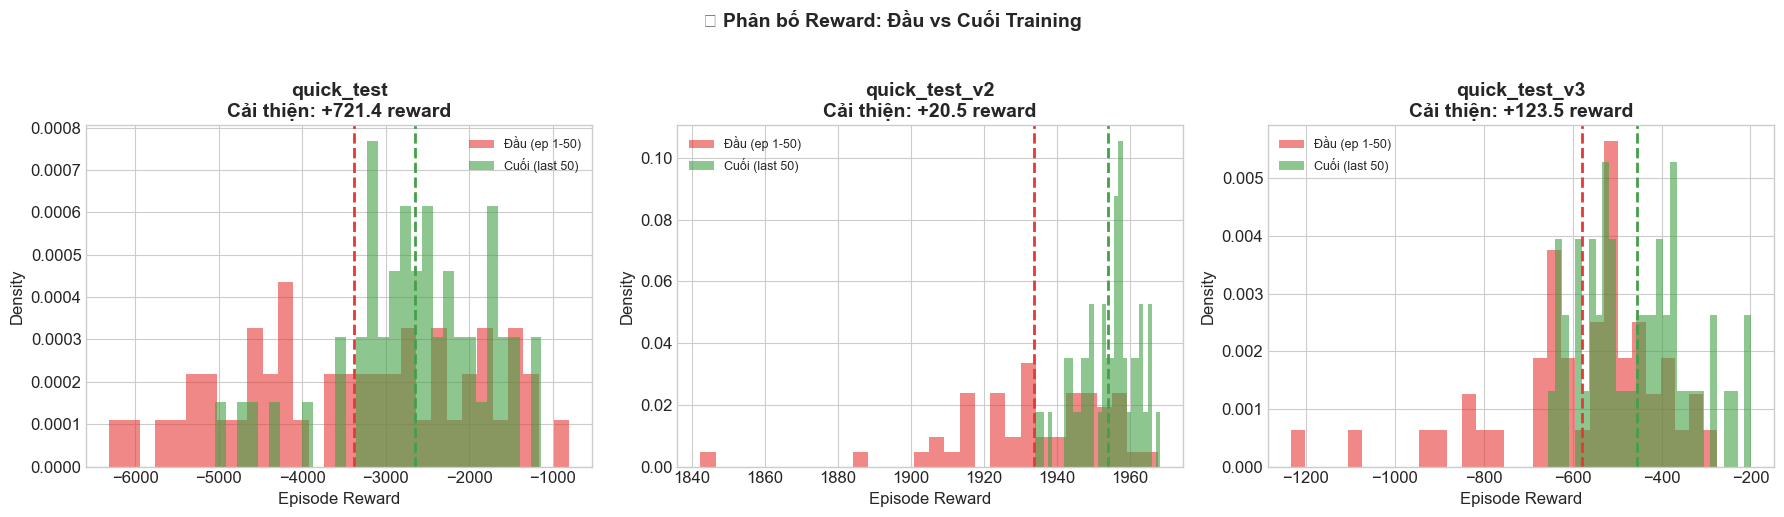

In [11]:
def plot_reward_distribution(all_runs, n_compare=200):
    """Histogram so sánh reward đầu vs cuối training."""
    n_runs = len(all_runs)
    fig, axes = plt.subplots(1, n_runs, figsize=(6 * n_runs, 5), squeeze=False)
    
    for idx, (name, data) in enumerate(all_runs.items()):
        ax = axes[0, idx]
        rewards = data['episode_rewards']
        n = min(n_compare, len(rewards) // 2)
        
        early = rewards[:n]
        late = rewards[-n:]
        
        ax.hist(early, bins=30, alpha=0.6, color='#E53935', label=f'Đầu (ep 1-{n})', density=True)
        ax.hist(late, bins=30, alpha=0.6, color='#43A047', label=f'Cuối (last {n})', density=True)
        
        ax.axvline(np.mean(early), color='#E53935', linestyle='--', linewidth=2)
        ax.axvline(np.mean(late), color='#43A047', linestyle='--', linewidth=2)
        
        improvement = np.mean(late) - np.mean(early)
        ax.set_title(f'{name}\nCải thiện: {improvement:+.1f} reward', fontweight='bold')
        ax.set_xlabel('Episode Reward')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
    
    fig.suptitle('📊 Phân bố Reward: Đầu vs Cuối Training', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

plot_reward_distribution(all_runs)

---

## Kết luận

**Cách đọc kết quả:**
- Agent **tốt** khi: reward tăng dần, cost giảm, SLA ≥ 95%, dùng nhiều spot khi giá rẻ
- Agent **chưa tốt** khi: reward không converge, SLA < 95%, chỉ dùng on-demand (ko tiết kiệm)

**Hành động tiếp theo:**
- Nếu SLA thấp → tăng `sla_penalty` trong config
- Nếu cost cao → tăng `epsilon_decay` để agent explore nhiều hơn
- Nếu agent chỉ "Do Nothing" → kiểm tra reward shaping, có thể reward quá negative

**Chạy lại notebook với run mới:** chỉ cần thêm `metrics.pkl` vào `results/<tên_run>/<timestamp>/` và re-run all cells.